In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import cftime
import sys
import os
import pandas as pd

calc_annual = False
read_last_n = False
read_first_n = False
nfiles = 120

#Additional plots
plot_total = True

# Conversion factors
km2_to_m2 = 1e6
kg_to_Gt = 1e-12
CO2_to_C = 12.011 / 44.01  # Conversion factor from CO2 to C
seconds_per_year = 365 * 24 * 60 * 60
days_per_year = 365
days_per_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
sec_per_month = [days * 24 * 60 * 60 for days in days_per_month]


variables = ["FCO2"]

case_dir = '/datalake/NS9188K/share/jessien/feb26/ne16_transient_1900.2026-02-06/run'

# Find all timeseries files
timeseries_files = sorted(glob.glob(f'{case_dir}/*.clm2.h0a*-*.nc'))

# Initialize a dictionary to store the accumulated results
results = {var: [] for var in variables}
results_NH = {var: [] for var in variables}
results_SH = {var: [] for var in variables}
time = []
co2_conc = []
fates_LU_area = []
if calc_annual:
    timeseries_files = timeseries_files[:-1]
if read_last_n:
    timeseries_files = timeseries_files[-nfiles:]
elif read_first_n:
    timeseries_files = timeseries_files[:nfiles]



In [2]:
# Loop through all timeseries files
first_file=True
for filename in timeseries_files[:]:
    print(f"Processing file: {filename}")
    mon=filename.split('.')[-2][-2:]
    mon_index=int(mon)-1
    print(f"Month index: {mon_index}")
    try:
        with xr.open_dataset(filename, engine='netcdf4', decode_timedelta=True) as data:            
            if first_file:
                area = data["area"].fillna(0)
                landfrac = data["landfrac"].fillna(0)               
                
            for var in variables:
                if var in data:
                    var_data_in = data[var]                                        
                    var_data = var_data_in
                    
                    # Determine spatial dimensions
                    
                    spatial_dims = ("lndgrid",)
                    
                    if first_file:
                        print(f'Reading {var}, with units: {data[var].units}')
                    # Carbon pools: multiply by area and landfrac (convert m^2 to km^2)
                    area_land_m2 = area * km2_to_m2 * landfrac
                    
                    total = (var_data * area_land_m2 * kg_to_Gt * CO2_to_C * sec_per_month[mon_index])
                    NH = total.where(data['lat'] > 0).sum(dim=spatial_dims)
                    SH = total.where(data['lat'] < 0).sum(dim=spatial_dims)

                    results[var].append(total.sum(dim=spatial_dims).values)
                    results_NH[var].append(NH.values)
                    results_SH[var].append(SH.values)
                    
            first_file = False
            time.append(data['time'].values)
    except FileNotFoundError:
        print(f"File not found: {filename}")
    except ValueError as e:
        print(f"Error reading the file: {e}")



Processing file: /datalake/NS9188K/share/jessien/feb26/ne16_transient_1900.2026-02-06/run/ne16_transient_1900.2026-02-06.clm2.h0a.1901-01.nc
Month index: 0
Reading FCO2, with units: kgCO2/m2/s
Processing file: /datalake/NS9188K/share/jessien/feb26/ne16_transient_1900.2026-02-06/run/ne16_transient_1900.2026-02-06.clm2.h0a.1901-02.nc
Month index: 1
Processing file: /datalake/NS9188K/share/jessien/feb26/ne16_transient_1900.2026-02-06/run/ne16_transient_1900.2026-02-06.clm2.h0a.1901-03.nc
Month index: 2
Processing file: /datalake/NS9188K/share/jessien/feb26/ne16_transient_1900.2026-02-06/run/ne16_transient_1900.2026-02-06.clm2.h0a.1901-04.nc
Month index: 3
Processing file: /datalake/NS9188K/share/jessien/feb26/ne16_transient_1900.2026-02-06/run/ne16_transient_1900.2026-02-06.clm2.h0a.1901-05.nc
Month index: 4
Processing file: /datalake/NS9188K/share/jessien/feb26/ne16_transient_1900.2026-02-06/run/ne16_transient_1900.2026-02-06.clm2.h0a.1901-06.nc
Month index: 5
Processing file: /datalake/

In [3]:
# Convert lists to numpy arrays
for var in variables:
    print(f"Processing {var}")
    if len(results_NH[var]) > 0:
        results_NH[var] = np.concatenate(results_NH[var])
    else:
        results_NH[var] = np.array([])


for var in variables:
    print(f"Processing {var}")
    if len(results_SH[var]) > 0:
        results_SH[var] = np.concatenate(results_SH[var])
    else:
        results_SH[var] = np.array([])

for var in variables:
    print(f"Processing {var}")
    if len(results[var]) > 0:
        results[var] = np.concatenate(results[var])
    else:
        results[var] = np.array([])

if len(time) > 0:
    time = np.concatenate(time)
else:
    time = np.array([])


Processing FCO2
Processing FCO2
Processing FCO2


In [4]:
# read in GCP data - note units are GtC yr-1 
GCP = pd.read_csv('/datalake/NS9188K/share/jessien/S3_nbp_transposed.csv')

GCP.head(3)

# get just years 1900-2020
GCP = GCP[(GCP['Year'] >= 1900) & (GCP['Year'] <= 2020)]
print(GCP.head(3))


years = GCP['Year'].values


# make a column with the multi model mean 
GCP['MMM'] = GCP.iloc[:, 1:].mean(axis=1)


     Year  CABLE-POP  CARDAMOM   CLASSIC  CLM-FATES    CLM6.0      DLEM  \
200  1900   1.734214       NaN  0.311607   0.087335 -0.287418 -1.739497   
201  1901  -1.036334       NaN -1.577377   1.068029 -0.373606 -2.083256   
202  1902   1.150704       NaN  2.613623   0.384267 -0.699585 -0.485515   

         E3SM      EDv3  ELM-FATES  ...      IBIS      ISAM    JSBACH  \
200  0.207931  0.866747   0.450078  ...  0.112258 -0.462238 -0.074293   
201  0.081889 -0.095537  -0.625515  ... -0.122521 -0.743535 -1.720650   
202 -0.769942  0.841467  -0.466337  ... -0.778028 -1.077928  0.769885   

        JULES  LPJ-EOSIM  LPJ-GUESS     LPJmL  LPX-Bern  ORCHIDEE  VISIT-UT  
200  0.257869  -0.075121  -1.034622 -0.826814  0.127180  0.039695  0.269518  
201 -0.574900  -0.319653   0.321044 -0.189482 -0.562129 -0.134119 -0.204295  
202 -0.737733  -0.838781  -0.759043 -1.625371 -1.573038 -0.522510 -1.712249  

[3 rows x 21 columns]


In [5]:
time = np.linspace(1900, 2020, len(results["FCO2"]))

In [6]:
tmp_NH = results_NH['FCO2']
tmp_SH = results_SH['FCO2']
tmp = results['FCO2']

yearly_avgs_NH = np.sum(tmp_NH.reshape((len(tmp_NH)//12, 12)), axis=1)
time_yrs = np.linspace(1900, 2020, len(yearly_avgs_NH))

yearly_avgs_SH = np.sum(tmp_SH.reshape((len(tmp_SH)//12, 12)), axis=1)
yearly_avgs_total = np.sum(tmp.reshape((len(tmp)//12, 12)), axis=1)

In [8]:
# save the global time series of NBP to file
output_df = pd.DataFrame({
    'Year': time_yrs,
    'NBP_Total': yearly_avgs_total,
    'NBP_NH': yearly_avgs_NH,
    'NBP_SH': yearly_avgs_SH
})
output_df.to_csv('/datalake/NS9188K/share/jessien/NBP_timeseries.csv', index=False)

In [9]:
output_df.head(5)

,Year,NBP_Total,NBP_NH,NBP_SH
0,1900.000000,0.772893,0.612378,0.160515
1,1901.008403,1.841114,1.339735,0.501380
2,1902.016807,1.974607,1.197150,0.777457
3,1903.025210,0.839022,0.733118,0.105903
4,1904.033613,1.723966,1.364075,0.359891


Number of years in FCO2: 120.0


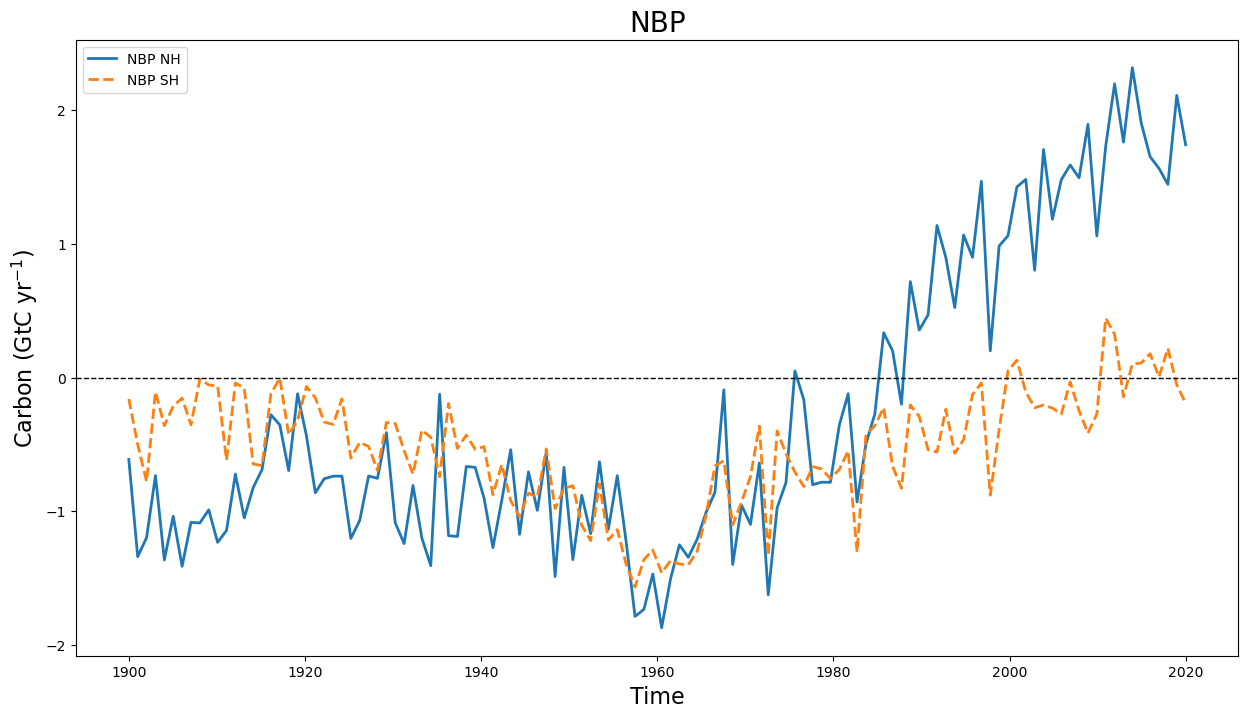

In [7]:

nyears = results_NH["FCO2"].shape[0] / 12
print(f'Number of years in FCO2: {nyears}')

# Plotting
figTot, axes = plt.subplots(1, 1, figsize=(15, 8))

axes.plot(time_yrs, -yearly_avgs_NH, label="NBP NH", linestyle='-', linewidth=2)
axes.plot(time_yrs, -yearly_avgs_SH, label="NBP SH", linestyle='--', linewidth=2)

axes.set_title('NBP', fontsize=20)
axes.set_ylabel(r'Carbon (GtC yr$^{-1}$)', fontsize=16)
axes.set_xlabel('Time', fontsize=16)
#axes.grid(True)
# add a horizontal line at y=0
axes.axhline(0, color='black', linestyle='--', linewidth=1)
axes.legend()

In [10]:
# Get cumulative sum of NBP for NH, SH, and total from 2000 onwards
NH_21C = yearly_avgs_NH[time_yrs >= 2000]
NH_21C[0] = 0.0
cumulative_NH = np.cumsum(NH_21C)


In [13]:
yrs_21C = time_yrs[time_yrs >= 2000]

In [18]:
# read in data from Randerson et al. 
ciaisNH = pd.read_csv('/datalake/NS9188K/share/jessien/randerson_data/fig2/CiaisNH.csv')
ciaisNH.head(3)

,year,Sum(NBP)
0,2000.5,0.00
1,2001.5,1.66
2,2002.5,2.79


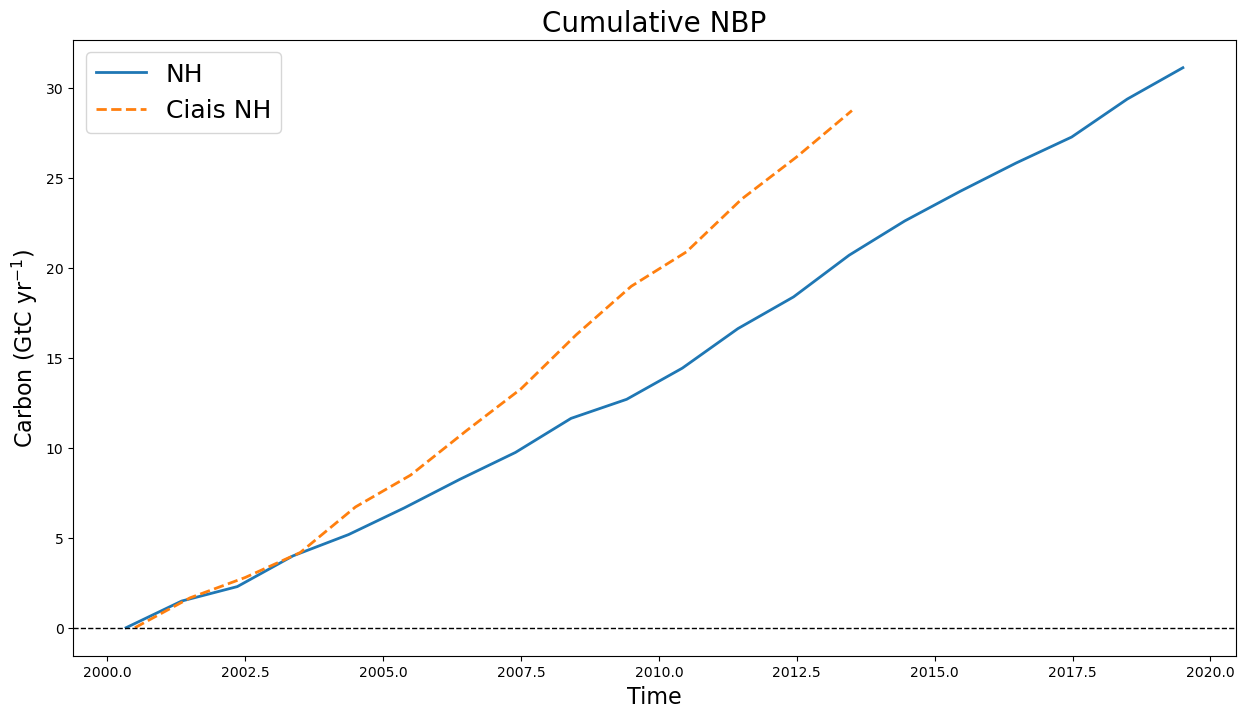

In [22]:
# Plotting
figTot, axes = plt.subplots(1, 1, figsize=(15, 8))

axes.plot(yrs_21C - 0.5, -cumulative_NH, label="NH", linestyle='-', linewidth=2)
axes.plot(ciaisNH['year'], ciaisNH['Sum(NBP)'], label='Ciais NH', linestyle='--', linewidth=2)

axes.set_title('Cumulative NBP', fontsize=20)
axes.set_ylabel(r'Carbon (GtC yr$^{-1}$)', fontsize=16)
axes.set_xlabel('Time', fontsize=16)
#axes.grid(True)
# add a horizontal line at y=0
axes.axhline(0, color='black', linestyle='--', linewidth=1)
axes.legend(fontsize=18)